In [2]:
import os
import sys
sys.path.append(os.path.abspath("../../../"))



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from main.classes.neural_networks.training.train_arima import train_and_evaluate_arima, load_data

In [5]:
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)

os.makedirs(model_dir, exist_ok=True)

df = load_data(csv_path)

target = "VALE3"

In [6]:
try:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, target, order, model_dir, version)
    
    print(f"\nMétricas do modelo ARIMA para {target}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
except Exception as e:
    print(f"Erro durante o treinamento: {e}")


2025-06-08 11:45:15,732 - INFO - Carregando dados para VALE3
2025-06-08 11:45:15,790 - INFO - Tamanho do treino: 2869 | Tamanho do teste: 455
c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.model_fit.forecast(steps=1)[0]
c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.model_fit.forecast(steps=1)[0]
c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\


Métricas do modelo ARIMA para VALE3:
MSE: 2.2215
RMSE: 1.4905
MAE: 1.1354
R2: 0.9678


In [7]:
# Carregar os valores reais e previstos
test_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_true_v{version}.npy"))
predicted_values = np.load(os.path.join(model_dir, f"{target}_arima_rolling_y_pred_v{version}.npy"))

# Obter as datas corretas
test_series = df[target].dropna()
test_dates = test_series.index[-len(test_values):]

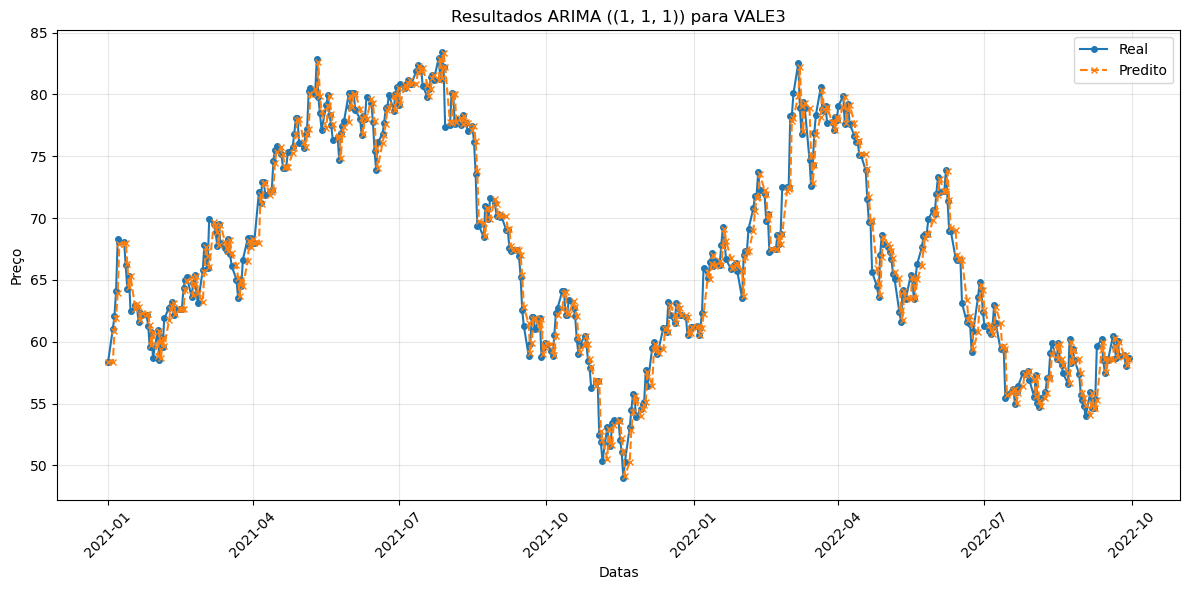

In [8]:
# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(test_dates, test_values, label='Real', marker='o', markersize=4)
plt.plot(test_dates, predicted_values, label='Predito', linestyle='--', marker='x', markersize=4)

plt.title(f"Resultados ARIMA ({order}) para {target}")
plt.xlabel('Datas')
plt.ylabel('Preço')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

2025-06-08 12:47:37,554 - INFO - Carregando dados para CMIG4
2025-06-08 12:47:37,597 - INFO - Tamanho do treino: 2869 | Tamanho do teste: 455
c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.model_fit.forecast(steps=1)[0]
c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\main\classes\neural_networks\architectures\arima_model.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return self.model_fit.forecast(steps=1)[0]
c:\Users\Emanuel\Desktop\Nova pasta (3)\analises-tcc-cripto\

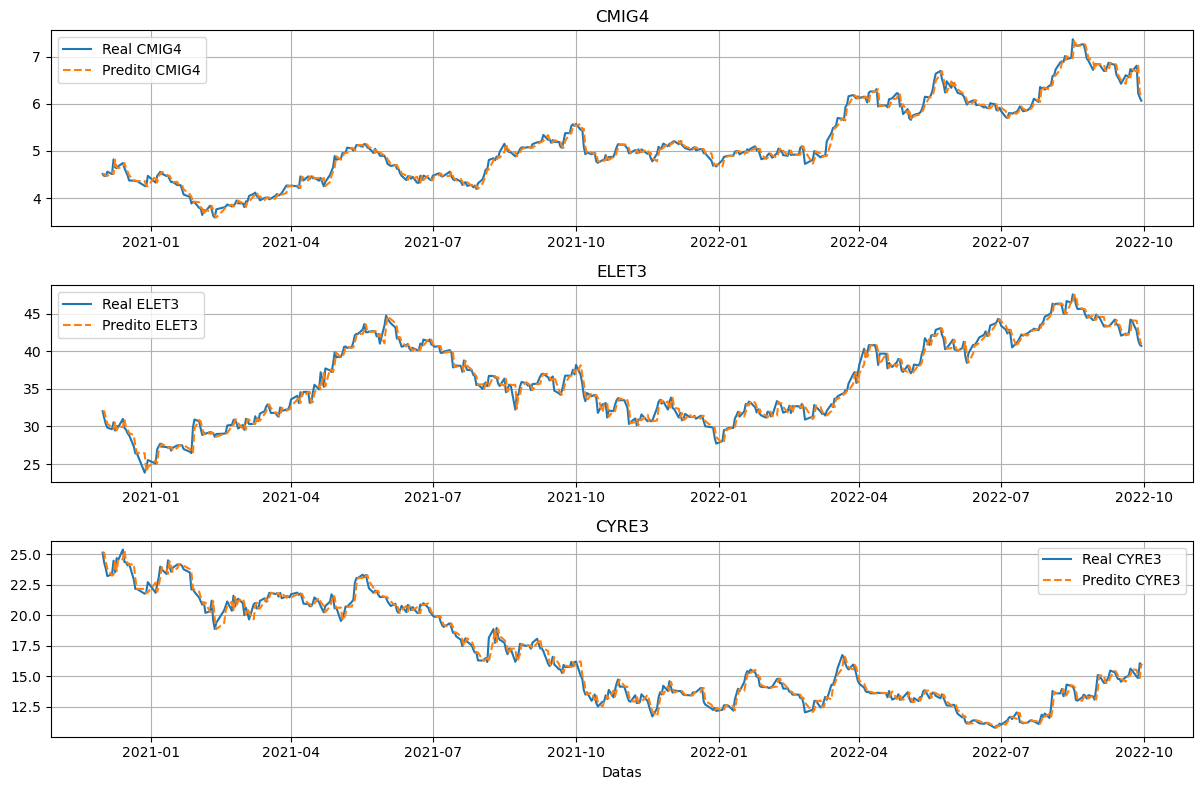

In [11]:
import matplotlib.pyplot as plt

# Configurações básicas
acoes = ["CMIG4", "ELET3", "CYRE3"]
csv_path = "../../datasets/b3_dados/processed/acoes_concat.csv"
model_dir = "../../saved_models/arima"
version = "1.0"
order = (1, 1, 1)  # Parâmetros ARIMA (p, d, q)

# Dicionário para armazenar os resultados
resultados_arima = {}
dates_map = {}

# Executa para cada ação
for acao in acoes:
    arima_model, metrics, predictions = train_and_evaluate_arima(csv_path, acao, order, model_dir, version)
    y_test = np.load(f"{model_dir}/{acao}_arima_rolling_y_true_v{version}.npy")
    resultados_arima[acao] = (y_test, predictions)

    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df = df.set_index('Date')
    df = df[df.index >= "2021-01-01"]
    dates_map[acao] = df.index[:len(y_test)]

# Visualiza os resultados em subplots
fig, axes = plt.subplots(len(acoes), 1, figsize=(12, 8), sharex=False)

for i, acao in enumerate(acoes):
    y_test, predictions = resultados_arima[acao]
    df = pd.read_csv(csv_path, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)

    # Obtem a série alvo completa (com datas)
    test_series = df[acao].dropna()
    test_dates = test_series.index[-len(y_test):]

    dates_map[acao] = test_dates
    axes[i].plot(test_dates, y_test, label=f'Real {acao}')
    axes[i].plot(test_dates, predictions, label=f'Predito {acao}', linestyle='--')
    axes[i].set_title(acao)
    axes[i].legend()
    axes[i].grid(True)

plt.xlabel('Datas')
plt.tight_layout()
plt.show()
